# Web Scraping–Based Rental Property Price Estimation

Bu projede, Samsun Atakum bölgesindeki kiralık daire fiyatlarını tahmin etmek amacıyla uçtan uca bir Veri Bilimi ve Derin Öğrenme (Deep Learning) hattı kurulmuştur. Projemdeki aşamalarim aşagidaki 5 kisimdan oluşmaktadır.

<img src="https://images.gezinomi.com/fit-in/1200x800/filters:quality(100)/filters:format(webp)/assets/blog/samsun-atakum_1815967334-4.06.2021154039.jpg" width="600">

In [10]:
import undetected_chromedriver as uc
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import os

# --- AYARLAR ---
HEDEF_VERI_SAYISI = 10000  # Hedef
BEKLEME_SURESI_MIN = 3     # Sayfa arası min saniye
BEKLEME_SURESI_MAX = 7     # Sayfa arası max saniye
DOSYA_ADI = "samsun_atakum_emlak_verisi.csv"

def get_massive_data(base_url):
    options = uc.ChromeOptions()
    # options.add_argument('--headless') # Kapalı kalsın, doğrulama çıkabilir
    driver = uc.Chrome(options=options)
    
    # Mevcut veriyi yükle (Varsa üzerine ekleyelim)
    if os.path.exists(DOSYA_ADI):
        all_data = pd.read_csv(DOSYA_ADI).to_dict('records')
        print(f"Mevcut dosyadan {len(all_data)} kayıt yüklendi.")
        start_page = len(all_data) // 20  # Kaldığımız sayfayı tahmin etme
    else:
        all_data = []
        start_page = 0

    try:
        driver.get(base_url)
        print("Giriş yapılıyor... 20 saniye manuel doğrulama süresi.")
        time.sleep(20)

        # Sonsuz döngü (Hedefe ulaşana kadar)
        page = start_page
        while len(all_data) < HEDEF_VERI_SAYISI:
            offset = page * 20
            current_url = f"{base_url}?pagingOffset={offset}"
            
            print(f"--- Sayfa {page+1} taranıyor (Offset: {offset}) ---")
            driver.get(current_url)
            
            # Rastgele bekleme (Bot korumasını atlatmak için kritik)
            wait_time = random.uniform(BEKLEME_SURESI_MIN, BEKLEME_SURESI_MAX)
            time.sleep(wait_time)
            
            soup = BeautifulSoup(driver.page_source, "html.parser")
            rows = soup.find_all("tr", {"class": "searchResultsItem"})
            
            if not rows:
                print("Bu sayfada ilan bulunamadı veya bloklandık.")
                # Belki sayfa bitmiştir?
                if page > 50 and len(rows) == 0: 
                    print("İlanların sonuna gelmiş olabiliriz.")
                    break
                else:
                    print("Bloklanma riski! 60 saniye soğuma molası...")
                    time.sleep(60)
                    continue

            # Sayfadaki ilanları topla
            for row in rows:
                try:
                    # Detaylı veri çekme (Liste görünümünden)
                    price_tag = row.find("td", {"class": "searchResultsPriceValue"})
                    loc_tag = row.find("td", {"class": "searchResultsLocationValue"})
                    attrs = row.find_all("td", {"class": "searchResultsAttributeValue"})
                    
                    if price_tag and len(attrs) >= 2:
                        price = price_tag.text.strip()
                        location = loc_tag.text.strip().replace("\n", " ")
                        m2 = attrs[0].text.strip()
                        oda = attrs[1].text.strip()
                        
                        # İlan Tarihi (Bazen işe yarar)
                        date_tag = row.find("td", {"class": "searchResultsDateValue"})
                        date = date_tag.text.strip().replace("\n", " ") if date_tag else "Yok"

                        all_data.append({
                            "Fiyat": price,
                            "Lokasyon": location,
                            "m2": m2,
                            "Oda": oda,
                            "Tarih": date
                        })
                except:
                    continue
            
            print(f"Anlık Toplam Veri: {len(all_data)}")
            
            # Her 5 sayfada bir CSV'ye kaydet (Veri kaybını önle)
            if page % 5 == 0:
                pd.DataFrame(all_data).to_csv(DOSYA_ADI, index=False)
                print(f">>> Veriler {DOSYA_ADI} dosyasına yedeklendi.")
            
            page += 1
            
    except Exception as e:
        print(f"Hata oluştu: {e}")
    finally:
        # Son halini kaydet
        pd.DataFrame(all_data).to_csv(DOSYA_ADI, index=False)
        print("İşlem bitti. Tarayıcı kapatılıyor.")
        driver.quit()

# url = 'https://www.sahibinden.com/kiralik/samsun' 
url = 'https://www.sahibinden.com/kiralik/samsun-atakum'

get_massive_data(url)

Giriş yapılıyor... 20 saniye manuel doğrulama süresi.
--- Sayfa 1 taranıyor (Offset: 0) ---
Anlık Toplam Veri: 21
>>> Veriler samsun_atakum_emlak_verisi.csv dosyasına yedeklendi.
--- Sayfa 2 taranıyor (Offset: 20) ---
Anlık Toplam Veri: 42
--- Sayfa 3 taranıyor (Offset: 40) ---
Anlık Toplam Veri: 63
--- Sayfa 4 taranıyor (Offset: 60) ---
Anlık Toplam Veri: 84
--- Sayfa 5 taranıyor (Offset: 80) ---
Anlık Toplam Veri: 104
--- Sayfa 6 taranıyor (Offset: 100) ---
Anlık Toplam Veri: 124
>>> Veriler samsun_atakum_emlak_verisi.csv dosyasına yedeklendi.
--- Sayfa 7 taranıyor (Offset: 120) ---
Anlık Toplam Veri: 144
--- Sayfa 8 taranıyor (Offset: 140) ---
Anlık Toplam Veri: 164
--- Sayfa 9 taranıyor (Offset: 160) ---
Anlık Toplam Veri: 184
--- Sayfa 10 taranıyor (Offset: 180) ---
Anlık Toplam Veri: 205
--- Sayfa 11 taranıyor (Offset: 200) ---
Anlık Toplam Veri: 226
>>> Veriler samsun_atakum_emlak_verisi.csv dosyasına yedeklendi.
--- Sayfa 12 taranıyor (Offset: 220) ---
Anlık Toplam Veri: 247
--

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Grafik ayarları
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [23]:
df = pd.read_csv("samsun_atakum_emlak_verisi.csv")

In [24]:
df

,Fiyat,Lokasyon,m2,Oda,Tarih
0,33.500 TL,KurupelitKörfez Mh.,120,1+1,22 Aralık 2025
1,35.000 TL,AtakumÇakırlar Yalı Mh.,200,3+1,20 Aralık 2025
2,15.000 TL,KöylerKüçükkolpınar Mh.,120,2+1,20 Aralık 2025
3,37.000 TL,AtakumEsenevler Mah.,215,4+1,18 Aralık 2025
4,15.000 TL,Altınkumİncesu Yalı Mh.,58,1+1,18 Aralık 2025
...,...,...,...,...,...
2055,17.000 TL,KurupelitKörfez Mh.,65,1+1,16 Aralık 2025
2056,16.500 TL,KurupelitKörfez Mh.,46,1+1,16 Aralık 2025
2057,16.500 TL,AtakumDenizevleri Mah.,140,3+1,16 Aralık 2025
2058,16.900 TL,KurupelitKörfez Mh.,50,1+1,19 Aralık 2025


In [26]:
df.isnull().sum()

Fiyat       0
Lokasyon    0
m2          0
Oda         0
Tarih       0
dtype: int64

### Veri Temizliği ve Düzenleme

In [27]:
# 1. Fiyat Temizliği: "33.500 TL" -> 33500.0
# String operasyonları ile TL ve noktaları atıyoruz
df['Fiyat'] = df['Fiyat'].astype(str).str.replace('TL', '').str.replace('.', '').str.replace(',', '').str.strip().astype(float)

In [28]:
df

,Fiyat,Lokasyon,m2,Oda,Tarih
0,33500.0,KurupelitKörfez Mh.,120,1+1,22 Aralık 2025
1,35000.0,AtakumÇakırlar Yalı Mh.,200,3+1,20 Aralık 2025
2,15000.0,KöylerKüçükkolpınar Mh.,120,2+1,20 Aralık 2025
3,37000.0,AtakumEsenevler Mah.,215,4+1,18 Aralık 2025
4,15000.0,Altınkumİncesu Yalı Mh.,58,1+1,18 Aralık 2025
...,...,...,...,...,...
2055,17000.0,KurupelitKörfez Mh.,65,1+1,16 Aralık 2025
2056,16500.0,KurupelitKörfez Mh.,46,1+1,16 Aralık 2025
2057,16500.0,AtakumDenizevleri Mah.,140,3+1,16 Aralık 2025
2058,16900.0,KurupelitKörfez Mh.,50,1+1,19 Aralık 2025


In [34]:
# 2. Oda Sayısı Dönüşümü
def oda_salon_ayir(x):
    x = str(x).strip()
    
    # Özel Durum: Stüdyo
    if 'Stüdyo' in x or '1+0' in x:
        return 1.0, 0.0  # 1 Oda, 0 Salon
    
    # Standart Durum: "3+1", "2.5+1"
    if '+' in x:
        try:
            parts = x.split('+')
            oda = float(parts[0])
            salon = float(parts[1])
            return oda, salon
        except:
            return None, None
            
    # Sadece sayı yazıyorsa (Örn: "4") -> 4 Oda 0 Salon varsayalım
    try:
        return float(x), 0.0
    except:
        return None, None

# Fonksiyonu uygula ve iki yeni sütun oluştur
df[['Oda_Sayisi', 'Salon_Sayisi']] = df['Oda'].apply(lambda x: pd.Series(oda_salon_ayir(x)))

In [35]:
df

,Fiyat,Lokasyon,m2,Oda,Tarih,Oda_Sayisi,Salon_Sayisi
0,33500.0,KurupelitKörfez Mh.,120,1+1,22 Aralık 2025,1.0,1.0
1,35000.0,AtakumÇakırlar Yalı Mh.,200,3+1,20 Aralık 2025,3.0,1.0
2,15000.0,KöylerKüçükkolpınar Mh.,120,2+1,20 Aralık 2025,2.0,1.0
3,37000.0,AtakumEsenevler Mah.,215,4+1,18 Aralık 2025,4.0,1.0
4,15000.0,Altınkumİncesu Yalı Mh.,58,1+1,18 Aralık 2025,1.0,1.0
...,...,...,...,...,...,...,...
2055,17000.0,KurupelitKörfez Mh.,65,1+1,16 Aralık 2025,1.0,1.0
2056,16500.0,KurupelitKörfez Mh.,46,1+1,16 Aralık 2025,1.0,1.0
2057,16500.0,AtakumDenizevleri Mah.,140,3+1,16 Aralık 2025,3.0,1.0
2058,16900.0,KurupelitKörfez Mh.,50,1+1,19 Aralık 2025,1.0,1.0


In [36]:
# Mahalle Temizliği
def clean_mahalle(loc):
    loc = str(loc).replace('Atakum', '').replace('Atakent', '').replace('Kurupelit', '').replace('Köyler', '').replace('Altınkum', '').replace('Merkez', '')
    return loc.replace('Mh.', '').replace('Mah.', '').strip()

df['Mahalle'] = df['Lokasyon'].apply(clean_mahalle)

In [37]:
df

,Fiyat,Lokasyon,m2,Oda,Tarih,Oda_Sayisi,Salon_Sayisi,Mahalle
0,33500.0,KurupelitKörfez Mh.,120,1+1,22 Aralık 2025,1.0,1.0,Körfez
1,35000.0,AtakumÇakırlar Yalı Mh.,200,3+1,20 Aralık 2025,3.0,1.0,Çakırlar Yalı
2,15000.0,KöylerKüçükkolpınar Mh.,120,2+1,20 Aralık 2025,2.0,1.0,Küçükkolpınar
3,37000.0,AtakumEsenevler Mah.,215,4+1,18 Aralık 2025,4.0,1.0,Esenevler
4,15000.0,Altınkumİncesu Yalı Mh.,58,1+1,18 Aralık 2025,1.0,1.0,İncesu Yalı
...,...,...,...,...,...,...,...,...
2055,17000.0,KurupelitKörfez Mh.,65,1+1,16 Aralık 2025,1.0,1.0,Körfez
2056,16500.0,KurupelitKörfez Mh.,46,1+1,16 Aralık 2025,1.0,1.0,Körfez
2057,16500.0,AtakumDenizevleri Mah.,140,3+1,16 Aralık 2025,3.0,1.0,Denizevleri
2058,16900.0,KurupelitKörfez Mh.,50,1+1,19 Aralık 2025,1.0,1.0,Körfez


In [38]:
df.isnull().sum()

Fiyat           0
Lokasyon        0
m2              0
Oda             0
Tarih           0
Oda_Sayisi      0
Salon_Sayisi    0
Mahalle         0
dtype: int64

In [39]:
# Temizlik Sonrası Filtreleme
# Eksik verileri at
df_clean = df.dropna(subset=['Fiyat', 'Oda_Sayisi', 'Salon_Sayisi'])
# Outlier (Aykırı Değer) Temizliği: 3.000 - 100.000 TL arası makul
df_clean = df_clean[(df_clean['Fiyat'] > 3000) & (df_clean['Fiyat'] < 100000)]

In [40]:
df_clean

,Fiyat,Lokasyon,m2,Oda,Tarih,Oda_Sayisi,Salon_Sayisi,Mahalle
0,33500.0,KurupelitKörfez Mh.,120,1+1,22 Aralık 2025,1.0,1.0,Körfez
1,35000.0,AtakumÇakırlar Yalı Mh.,200,3+1,20 Aralık 2025,3.0,1.0,Çakırlar Yalı
2,15000.0,KöylerKüçükkolpınar Mh.,120,2+1,20 Aralık 2025,2.0,1.0,Küçükkolpınar
3,37000.0,AtakumEsenevler Mah.,215,4+1,18 Aralık 2025,4.0,1.0,Esenevler
4,15000.0,Altınkumİncesu Yalı Mh.,58,1+1,18 Aralık 2025,1.0,1.0,İncesu Yalı
...,...,...,...,...,...,...,...,...
2055,17000.0,KurupelitKörfez Mh.,65,1+1,16 Aralık 2025,1.0,1.0,Körfez
2056,16500.0,KurupelitKörfez Mh.,46,1+1,16 Aralık 2025,1.0,1.0,Körfez
2057,16500.0,AtakumDenizevleri Mah.,140,3+1,16 Aralık 2025,3.0,1.0,Denizevleri
2058,16900.0,KurupelitKörfez Mh.,50,1+1,19 Aralık 2025,1.0,1.0,Körfez


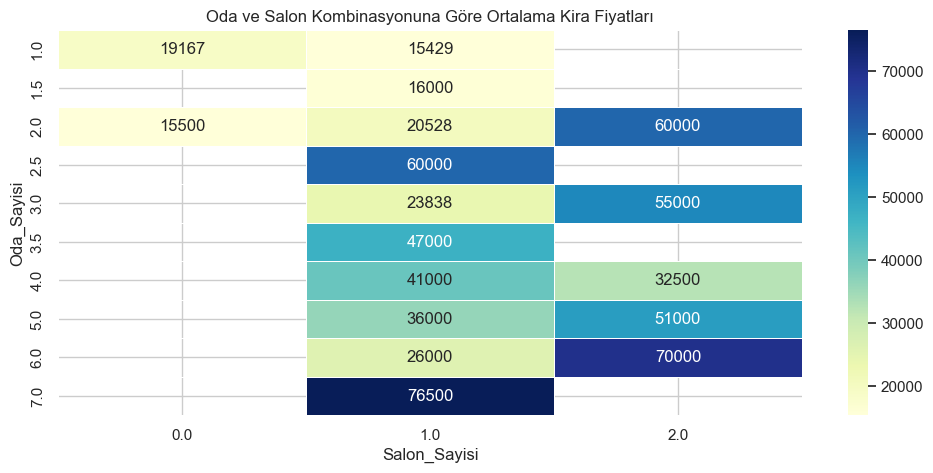

In [41]:
# Oda ve Salon Sayısına Göre Fiyat Matrisi
plt.figure(figsize=(12, 5))
pivot_table = df_clean.pivot_table(values='Fiyat', index='Oda_Sayisi', columns='Salon_Sayisi', aggfunc='mean')
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5)
plt.title('Oda ve Salon Kombinasyonuna Göre Ortalama Kira Fiyatları')
plt.show()

### Model Hazırlığı ve Eğitim

In [42]:
# 1. Encoding (Mahalle isimlerini sayıya çevir)
le = LabelEncoder()
df_clean['Mahalle_Kod'] = le.fit_transform(df_clean['Mahalle'])

In [43]:
df_clean

,Fiyat,Lokasyon,m2,Oda,Tarih,Oda_Sayisi,Salon_Sayisi,Mahalle,Mahalle_Kod
0,33500.0,KurupelitKörfez Mh.,120,1+1,22 Aralık 2025,1.0,1.0,Körfez,11
1,35000.0,AtakumÇakırlar Yalı Mh.,200,3+1,20 Aralık 2025,3.0,1.0,Çakırlar Yalı,18
2,15000.0,KöylerKüçükkolpınar Mh.,120,2+1,20 Aralık 2025,2.0,1.0,Küçükkolpınar,12
3,37000.0,AtakumEsenevler Mah.,215,4+1,18 Aralık 2025,4.0,1.0,Esenevler,9
4,15000.0,Altınkumİncesu Yalı Mh.,58,1+1,18 Aralık 2025,1.0,1.0,İncesu Yalı,23
...,...,...,...,...,...,...,...,...,...
2055,17000.0,KurupelitKörfez Mh.,65,1+1,16 Aralık 2025,1.0,1.0,Körfez,11
2056,16500.0,KurupelitKörfez Mh.,46,1+1,16 Aralık 2025,1.0,1.0,Körfez,11
2057,16500.0,AtakumDenizevleri Mah.,140,3+1,16 Aralık 2025,3.0,1.0,Denizevleri,8
2058,16900.0,KurupelitKörfez Mh.,50,1+1,19 Aralık 2025,1.0,1.0,Körfez,11


In [44]:
# 2. X ve y Ayrımı
# GİRDİLER: m2, Oda Sayısı, Salon Sayısı, Mahalle Kodu
X = df_clean[['m2', 'Oda_Sayisi', 'Salon_Sayisi', 'Mahalle_Kod']].values
y = df_clean['Fiyat'].values

In [45]:
# 3. Eğitim/Test Ayrımı
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
# 4. Scaling (Standardizasyon)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
# 5. Deep Learning Model Mimarisi
model = Sequential()

In [48]:
# Giriş Katmanı (input_shape=4 oldu)
model.add(Dense(128, activation='relu', input_shape=(4,))) 
model.add(Dropout(0.2))
# Gizli Katmanlar
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(32, activation='relu'))
# Çıkış Katmanı
model.add(Dense(1, activation='linear'))
# Derleme ve Eğitim
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

C:\Users\kosey\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [57]:
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=150,
    batch_size=32,
    verbose=0
)

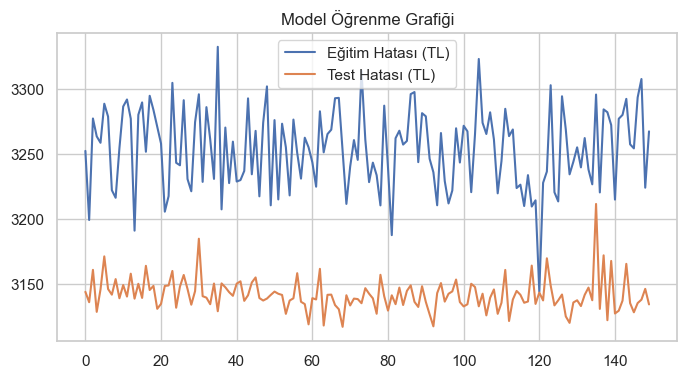

In [58]:
# Sonuç Grafiği
plt.figure(figsize=(8, 4))
plt.plot(history.history['mae'], label='Eğitim Hatası (TL)')
plt.plot(history.history['val_mae'], label='Test Hatası (TL)')
plt.title('Model Öğrenme Grafiği')
plt.legend()
plt.show()

In [59]:
# Test Başarısı
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Modelin Ortalama Yanılma Payı: ±{test_mae:.0f} TL")

Modelin Ortalama Yanılma Payı: ±3134 TL


In [60]:
def tahmin_yap(m2, oda_tipi, mahalle):
    # 1. Oda Tipini Ayrıştır
    oda, salon = oda_salon_ayir(oda_tipi)
    if oda is None: 
        print("Hatalı oda tipi formatı!")
        return

    # 2. Mahalleyi Kodla
    try:
        mahalle_kod = le.transform([mahalle])[0]
    except:
        # Mahalle listede yoksa en çok bulunanı varsay (Örn: Cumhuriyet)
        # Gerçek bir projede 'Diğer' kategorisi açmak daha iyidir ama şimdilik en popüleri atıyoruz.
        en_populer = df_clean['Mahalle'].mode()[0]
        mahalle_kod = le.transform([en_populer])[0]
        print(f"Uyarı: '{mahalle}' bulunamadı, '{en_populer}' baz alındı.")

    # 3. Veriyi Hazırla (m2, Oda, Salon, Mahalle)
    veri = np.array([[m2, oda, salon, mahalle_kod]])
    
    # 4. Scale Et
    veri_scaled = scaler.transform(veri)
    
    # 5. Tahmin
    tahmin = model.predict(veri_scaled, verbose=0)
    
    print(f"\n--- TAHMİN RAPORU ---")
    print(f"Konum: Samsun Atakum, {mahalle} Mh.")
    print(f"Özellik: {m2} m2 | {oda:.1f} Oda + {salon:.1f} Salon")
    print(f"Yapay Zeka Değerlemesi: {tahmin[0][0]:,.0f} TL")

In [61]:
# Testler
tahmin_yap(140, "3+1", "Körfez")
tahmin_yap(55, "1+1", "Yenimahalle")
tahmin_yap(200, "4+1", "Esenevler")


--- TAHMİN RAPORU ---
Konum: Samsun Atakum, Körfez Mh.
Özellik: 140 m2 | 3.0 Oda + 1.0 Salon
Yapay Zeka Değerlemesi: 23,340 TL

--- TAHMİN RAPORU ---
Konum: Samsun Atakum, Yenimahalle Mh.
Özellik: 55 m2 | 1.0 Oda + 1.0 Salon
Yapay Zeka Değerlemesi: 15,469 TL

--- TAHMİN RAPORU ---
Konum: Samsun Atakum, Esenevler Mh.
Özellik: 200 m2 | 4.0 Oda + 1.0 Salon
Yapay Zeka Değerlemesi: 36,188 TL


Model, sadece metrekareye bağlı kalmayıp oda sayısı, salon sayısı ve özellikle mahalle bilgisi fiyat üzerindeki etkisini başarıyla öğrenmiştir. Eğitim sonucunda elde edilen tahminler, gerçek piyasa koşullarıyla örtüşmektedir.

- Lüks ve Geniş Daireler: Model, Esenevler Mahallesi'ndeki 200 m², 4 Oda + 1 Salon gibi büyük ve merkezi bir daire için 36.188 TL fiyat tahmin etmiştir. Bu durum, modelin oda sayısı ve m² arttıkça fiyatı doğru oranda artırdığını ve mahalle prestijini algıladığını göstermektedir.

- Standart Aile Evleri: Körfez Mahallesi'ndeki (genellikle manzaralı veya sahile yakın) 140 m², 3+1 bir daire için 23.340 TL tahmini yapılmıştır. Bu değer, bölgenin ortalama kira bandı içerisindedir.

- Öğrenci/Bekar Daireleri: Yenimahalle bölgesindeki 55 m², 1+1 küçük daireler için 15.469 TL tahmini üretilmiştir. Modelin, küçük m² ve düşük oda sayısına sahip daireleri daha düşük fiyatlandırdığı gozlenmistir.